In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:
df = pd.read_excel("yelp_final_merged_data.xlsx")
print(df.shape)
print(df.head())
print(df.info()) 

(215912, 25)
   index             business_id                 user_id  stars  \
0      0  yE1raqkLX7OZsjmX3qKIKg  j4qNLF-VNRF2DwBkUENW-w      5   
1      1  oQ5CPRt0R3AzFvcjNOqB1w  H3P9EB7J9HP6PzkVjgFiOg      5   
2      2  NDHgJsy-4Lb6WhERPXPs0A  DKoZaUmK18zmMU6kR2H85A      5   
3      3  TXoxXn3IETBBJxZQMQK3rw  MiCgkSaHP30aqPEAtHnPyw      5   
4      4  nohJqY1rHip5gXrVGOMlIA  wsj699cGyqR-rzFGFcnL6Q      5   

                  date  text_len  \
0  2021-01-27 23:28:03        52   
1  2021-03-17 20:09:00       104   
2  2021-01-21 17:09:08        45   
3  2021-01-25 00:58:08        54   
4  2021-01-25 22:38:08        30   

                                                text  \
0  two words: whipped. feta. \nexplosion of amazi...   
1  So day 2 in Nashville. I gotta get some BBQ. M...   
2  I happened upon this coffee shop while looking...   
3  Came to find this restaurant through Yelp, pri...   
4  Absolutely incredible. The best service I've e...   

                       biz_nam

# user segmentation

In [3]:
# 以 user_id 为单位聚合，得到“用户行为特征表”
user_df = df.groupby("user_id").agg(
    user_review_count=("user_review_count", "first"),      # 这个字段本来就是用户层面的
    user_average_stars=("user_average_stars", "first"),
    user_fans=("user_fans", "first"),
    
    mean_review_stars=("stars", "mean"),                   # 这个用户给别人的平均评分
    mean_text_len=("text_len", "mean"),                    # 平均评论长度
    mean_biz_stars=("biz_stars", "mean"),                  # 他常去的店的平均评分
    mean_checkin=("checkin_count", "mean"),                # 他常去的店平均 checkin 数
    
    n_business=("business_id", "nunique"),                 # 不同商家数
    n_reviews=("stars", "count")                           # 评论总数（在这张表里）
)

print("user_df shape:", user_df.shape)
print(user_df.head())
print(user_df.isnull().sum())

user_df shape: (116719, 9)
                        user_review_count  user_average_stars  user_fans  \
user_id                                                                    
--4T2OChSFzSvcYG8-lQPA                 15                4.73          0   
--5jn4JKkqN83PRGdizx4Q                  3                5.00          0   
--5sXVbD2Fi48Ln5UCtxeg                  1                1.00          0   
--5t79VnMbzUeoaOmpMoOg                  8                2.88          0   
--6NOjQgN5tcpl_mPLt76Q                  2                5.00          0   

                        mean_review_stars  mean_text_len  mean_biz_stars  \
user_id                                                                    
--4T2OChSFzSvcYG8-lQPA                5.0           34.0             4.0   
--5jn4JKkqN83PRGdizx4Q                5.0           20.0             4.5   
--5sXVbD2Fi48Ln5UCtxeg                1.0           28.0             4.0   
--5t79VnMbzUeoaOmpMoOg                1.0           87.0    

In [4]:
# 只保留评论数 >= 3 的用户（行为更稳定一点）
user_df2 = user_df[user_df["n_reviews"] >= 3].copy()

print("user_df2 shape:", user_df2.shape)
print(user_df2.head())


user_df2 shape: (15532, 9)
                        user_review_count  user_average_stars  user_fans  \
user_id                                                                    
--u09WAjW741FdfkJXxNmg                263                3.98         68   
-0KMZFU7kI1D9iF73lExqw                 24                4.71          0   
-0MIp6WKJ8QvGnYZQ5ETyg                 49                3.69          0   
-0NMQ69U_7lMxmUV-wqK8g                  7                5.00          0   
-0bPEjGz18PzDz7nBogMhw                116                4.33          2   

                        mean_review_stars  mean_text_len  mean_biz_stars  \
user_id                                                                    
--u09WAjW741FdfkJXxNmg           3.888889     169.111111        4.111111   
-0KMZFU7kI1D9iF73lExqw           5.000000      34.800000        4.600000   
-0MIp6WKJ8QvGnYZQ5ETyg           4.333333     123.666667        4.166667   
-0NMQ69U_7lMxmUV-wqK8g           5.000000      67.333333    

In [5]:
feature_cols = [
    "user_review_count",   # Yelp 记录的总评论数
    "user_average_stars",  # 用户在 Yelp 的整体平均评分
    "user_fans",           # 粉丝数

    "mean_review_stars",   # 在我们样本里的平均打分
    "mean_text_len",       # 平均评论长度
    "mean_biz_stars",      # 去过的店平均评分
    "mean_checkin",        # 去过店的平均 checkin 数
    "n_business",          # 在我们样本中光顾的不同商家数
    "n_reviews",           # 在我们样本中的评论条数
]

X = user_df2[feature_cols].copy()
print(X.describe())


       user_review_count  user_average_stars     user_fans  mean_review_stars  \
count       15532.000000        15532.000000  15532.000000       15532.000000   
mean          104.035540            3.855410      8.535668           3.927449   
std           305.800207            0.775277     67.699019           0.979531   
min             1.000000            1.000000      0.000000           1.000000   
25%            12.000000            3.500000      0.000000           3.500000   
50%            32.000000            4.000000      0.000000           4.153846   
75%            94.000000            4.380000      3.000000           4.666667   
max         17473.000000            5.000000   3642.000000           5.000000   

       mean_text_len  mean_biz_stars  mean_checkin    n_business     n_reviews  
count   15532.000000    15532.000000  15532.000000  15532.000000  15532.000000  
mean       94.655497        3.936189    664.680362      6.221478      6.369817  
std        64.234766       

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)
print("每个特征的均值（应该接近 0）:")
print(np.mean(X_scaled, axis=0))
print("每个特征的标准差（应该接近 1）:")
print(np.std(X_scaled, axis=0))


X_scaled shape: (15532, 9)
每个特征的均值（应该接近 0）:
[-2.74482128e-18 -1.81615675e-16  3.65976171e-18 -2.56183320e-17
 -1.34953713e-16 -1.26261779e-16 -6.67906512e-17 -4.75769022e-17
 -1.82988085e-17]
每个特征的标准差（应该接近 1）:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


k=2, silhouette=0.276
k=3, silhouette=0.316
k=4, silhouette=0.318
k=5, silhouette=0.279
k=6, silhouette=0.273
k=7, silhouette=0.286
k=8, silhouette=0.220
k=9, silhouette=0.226
k=10, silhouette=0.227


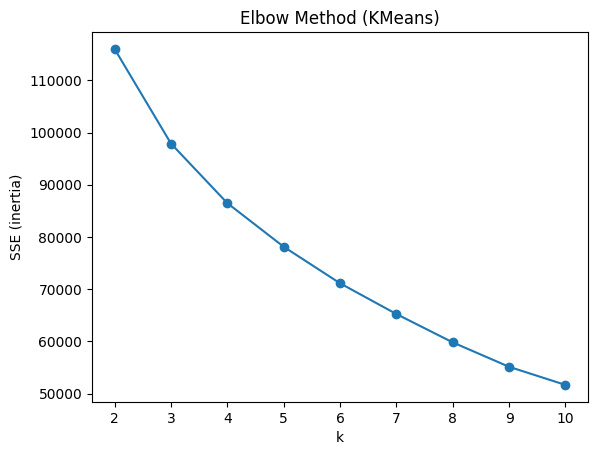

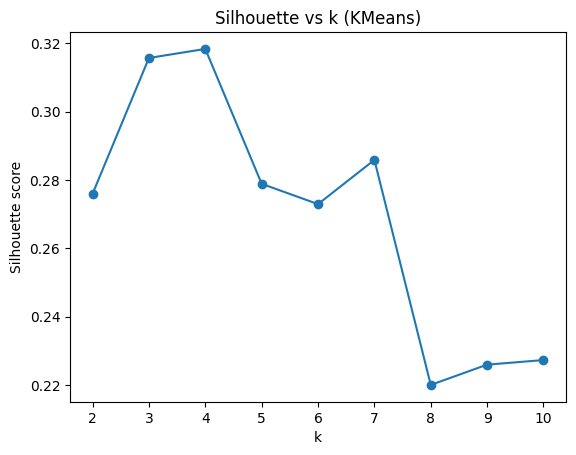

In [7]:
k_list = range(2, 11)
sse = []
sil_scores = []

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sse.append(kmeans.inertia_)                  # 簇内平方和（Elbow）
    sil = silhouette_score(X_scaled, labels)     # 轮廓系数
    sil_scores.append(sil)
    
    print(f"k={k}, silhouette={sil:.3f}")

# 画 elbow 曲线
plt.figure()
plt.plot(k_list, sse, marker="o")
plt.xlabel("k")
plt.ylabel("SSE (inertia)")
plt.title("Elbow Method (KMeans)")
plt.show()

# 画 silhouette 曲线
plt.figure()
plt.plot(k_list, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (KMeans)")
plt.show()


In [8]:
# 选定的聚类数
k_opt = 4

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# 把聚类结果写回 user_df2
user_df2["cluster"] = cluster_labels

# 看每个 cluster 有多少用户
print(user_df2["cluster"].value_counts().sort_index())


cluster
0      809
1     3514
2    11196
3       13
Name: count, dtype: int64


In [9]:
cluster_profile = user_df2.groupby("cluster")[feature_cols].mean()
print(cluster_profile)


         user_review_count  user_average_stars    user_fans  \
cluster                                                       
0               319.634116            4.123881    30.741656   
1                46.349175            2.835552     1.793682   
2               100.892908            4.155845     6.985977   
3              4986.769231            4.080000  1783.692308   

         mean_review_stars  mean_text_len  mean_biz_stars  mean_checkin  \
cluster                                                                   
0                 4.210909     132.344955        4.034283    580.450638   
1                 2.523625     100.437433        3.441840    433.439315   
2                 4.347233      89.980334        4.084167    742.943738   
3                 4.220893     212.703710        4.014454   1009.767280   

         n_business  n_reviews  
cluster                         
0         28.417800  29.260816  
1          4.255834   4.453899  
2          5.210432   5.293051  
3    

Cluster 2（普通正向型，Mainstream positive users，11196 人）
* user_review_count ≈ 101（中等活跃）
* user_average_stars ≈ 4.16，mean_review_stars ≈ 4.35（明显偏高分）
* user_fans ≈ 7（一点点粉丝）
* mean_text_len ≈ 90（评论中等长度）
* n_business ≈ 5.2，n_reviews ≈ 5.3（在我们样本中光顾店和评论条数不多）
* mean_biz_stars ≈ 4.08，mean_checkin ≈ 743（去的店评分高、checkin 多，偏热门好评店）
典型的高分好评用户，活跃度 OK，多给 4–5 星，经常去评分较高、比较热门的店。

Cluster 1（挑剔低分型，Critical users，3514 人）
* user_review_count ≈ 46（活跃度偏低/中）
* user_average_stars ≈ 2.84，mean_review_stars ≈ 2.52（整体打分很低）
* user_fans ≈ 1.8（几乎没粉丝）
* mean_text_len ≈ 100（长度还可以）
* mean_biz_stars ≈ 3.44（去的店本身评分比其他簇低）
* mean_checkin ≈ 433（店的热度中等）
* n_business ≈ 4.3，n_reviews ≈ 4.5
明显的“挑剔用户”/抱怨型用户：总体给分低，去的店评分也偏低，对商家打分比较严苛。

Cluster 0（活跃本地达人，Active local experts，809 人）
* user_review_count ≈ 320（比总体平均高很多）
* user_average_stars ≈ 4.12，mean_review_stars ≈ 4.21（偏高分）
* user_fans ≈ 31（有一定粉丝）
* mean_text_len ≈ 132（写得比较长）
* mean_biz_stars ≈ 4.03，mean_checkin ≈ 580（去的店评分高、也比较热门）
* n_business ≈ 28，n_reviews ≈ 29（在本数据里覆盖很多店）
高活跃、本地“美食达人”：写很多评论，去很多店，倾向给高分，对平台内容贡献度高，有一定影响力。

Cluster 3（超级大 V，Super influencers，13 人）
* user_review_count ≈ 4987（夸张的高）
* user_fans ≈ 1784（Yelp 大 V）
* mean_text_len ≈ 213（超长评论）
* 评分相关：user_average_stars ≈ 4.08，mean_review_stars ≈ 4.22（偏正向）
* n_business ≈ 27，n_reviews ≈ 27（在我们样本中覆盖很多店）
* mean_checkin ≈ 1010（去的店非常热门）
极少数的超级重度用户 / 网红大 V：评论数量和粉丝都远高于其他簇，对平台口碑影响最大。

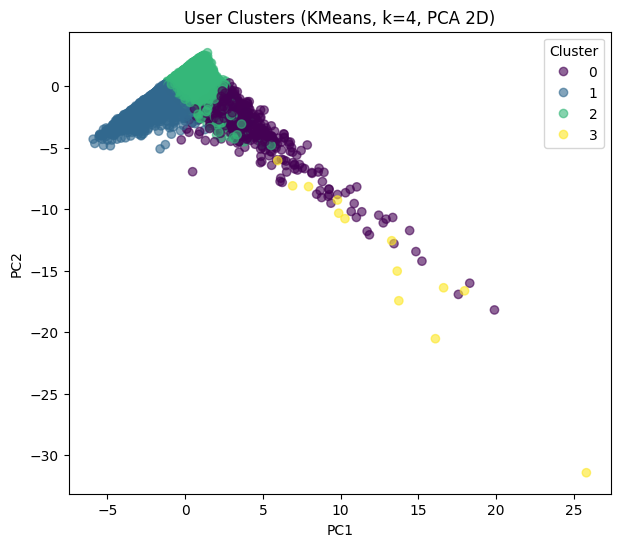

In [10]:
# PCA 降到 2 维
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 把 PC1/PC2 加回 user_df2，方便后面用
user_df2["PC1"] = X_pca[:, 0]
user_df2["PC2"] = X_pca[:, 1]

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    user_df2["PC1"],
    user_df2["PC2"],
    c=user_df2["cluster"],
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("User Clusters (KMeans, k=4, PCA 2D)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


In [11]:
# X 里是所有用户的原始特征
overall_mean = X.mean()
overall_std = X.std()

# 把每个 cluster 的均值标准化成 z-score
cluster_profile_z = (cluster_profile - overall_mean) / overall_std

print(cluster_profile_z.round(2))


         user_review_count  user_average_stars  user_fans  mean_review_stars  \
cluster                                                                        
0                     0.71                0.35       0.33               0.29   
1                    -0.19               -1.32      -0.10              -1.43   
2                    -0.01                0.39      -0.02               0.43   
3                    15.97                0.29      26.22               0.30   

         mean_text_len  mean_biz_stars  mean_checkin  n_business  n_reviews  
cluster                                                                      
0                 0.59            0.22         -0.09        3.15       3.13  
1                 0.09           -1.08         -0.23       -0.28      -0.26  
2                -0.07            0.32          0.08       -0.14      -0.15  
3                 1.84            0.17          0.35        2.95       2.83  


<Figure size 1000x600 with 0 Axes>

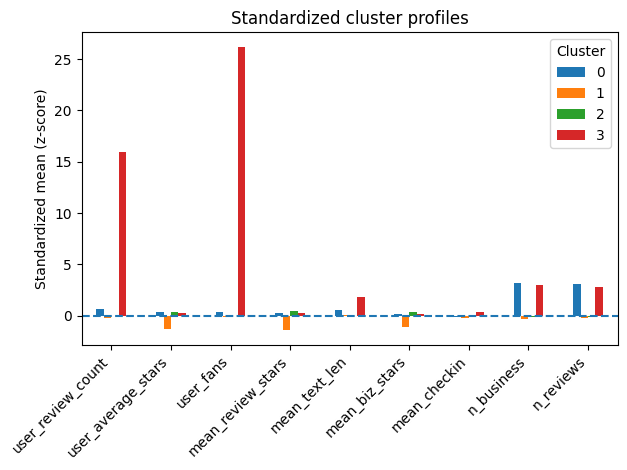

In [12]:
plt.figure(figsize=(10, 6))
cluster_profile_z.T.plot(kind="bar")
plt.axhline(0, linestyle="--")
plt.ylabel("Standardized mean (z-score)")
plt.title("Standardized cluster profiles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


Cluster 0（蓝色）

z-score：
* user_review_count ≈ +0.71
* user_average_stars ≈ +0.35，mean_review_stars ≈ +0.29
* user_fans ≈ +0.33
* mean_text_len ≈ +0.59
* mean_biz_stars ≈ +0.22
* mean_checkin ≈ -0.09（接近平均）
* n_business ≈ +3.15，n_reviews ≈ +3.13（非常高）

比平均用户明显更活跃（更多评论、更多商家）；
评论偏长，评分略偏高，粉丝略多；
去的店评分也稍微更好。
高活跃本地达人；Active local experts

Cluster 1（橙色）

z-score：
* user_average_stars ≈ -1.32
* mean_review_stars ≈ -1.43
* mean_biz_stars ≈ -1.08
* 其他变量都在 ±0.3 以内

打分明显比平均低很多，在我们样本里的平均评分接近 2.5 星；
他们去的店在 Yelp 上的总体评分也偏低；
活跃度、文本长度都比较普通。
挑剔低分型用户；Critical users

Cluster 2（绿色）

z-score：
* 所有指标基本在 [-0.2, +0.4] 内，最明显的是
* user_average_stars ≈ +0.39
* mean_review_stars ≈ +0.43
* mean_biz_stars ≈ +0.32

各方面都接近整体平均；
略偏向于给高分，也稍微更喜欢去高评分店。
普通正向型用户（主流人群）；Mainstream positive users

Cluster 2（绿色）

z-score：
* 所有指标基本在 [-0.2, +0.4] 内，最明显的是
* user_average_stars ≈ +0.39
* mean_review_stars ≈ +0.43
* mean_biz_stars ≈ +0.32

各方面都接近整体平均；
略偏向于给高分，也稍微更喜欢去高评分店。
普通正向型用户（主流人群）；Mainstream positive users

# business clustering

In [13]:
# 以 business_id 为单位聚合，得到“商家特征表”
biz_df = df.groupby("business_id").agg(
    biz_stars=("biz_stars", "mean"),                   # 商家整体评分
    biz_review_count=("biz_review_count", "first"),    # Yelp 上记录的评论数
    checkin_count=("checkin_count", "first"),          # 总 check-in 数
    is_open=("is_open", "first"),                      # 是否营业中 (0/1)

    mean_review_stars=("stars", "mean"),               # 用户给该店的平均评分
    mean_text_len=("text_len", "mean"),                # 该店评论平均长度

    mean_user_review_count=("user_review_count", "mean"),
    mean_user_average_stars=("user_average_stars", "mean"),
    mean_user_fans=("user_fans", "mean"),

    n_users=("user_id", "nunique"),                    # 不同用户数
    n_reviews=("stars", "count")                       # 评论总数（在本数据里）
)

print("biz_df shape:", biz_df.shape)
print(biz_df.head())
print(biz_df.isnull().sum())


biz_df shape: (26453, 11)
                        biz_stars  biz_review_count  checkin_count  is_open  \
business_id                                                                   
--9osgUCSDUWUkoTLdvYhQ        5.0                29             24        1   
--eBbs3HpZYIym5pEw8Qdw        2.5                24             28        1   
--hF_3v1JmU9nlu4zfXJ8Q        4.5                15              7        1   
--lqIzK-ZVTtgwiQM63XgQ        2.0                15             21        1   
--rS-rnOIZxoiDA8yctWpQ        5.0                 8             14        1   

                        mean_review_stars  mean_text_len  \
business_id                                                
--9osgUCSDUWUkoTLdvYhQ           5.000000      75.500000   
--eBbs3HpZYIym5pEw8Qdw           2.333333     129.666667   
--hF_3v1JmU9nlu4zfXJ8Q           4.692308      85.923077   
--lqIzK-ZVTtgwiQM63XgQ           2.000000      63.500000   
--rS-rnOIZxoiDA8yctWpQ           5.000000     130.875000   


In [14]:
# 只保留评论数 >= 5 的商家
biz_df2 = biz_df[biz_df["n_reviews"] >= 5].copy()

print("biz_df2 shape:", biz_df2.shape)
print(biz_df2.head())

# 选用于聚类的特征
biz_feature_cols = [
    "biz_stars",              # 商家整体评分
    "biz_review_count",       # Yelp 记录的总评论数
    "checkin_count",          # 总 check-in 数
    "is_open",                # 是否营业中

    "mean_review_stars",      # 我们样本里得到的平均评分
    "mean_text_len",          # 平均评论长度

    "mean_user_review_count", # 来访用户的平均活跃度
    "mean_user_average_stars",
    "mean_user_fans",

    "n_users",                # 不同用户数
    "n_reviews",              # 评论条数（本样本）
]

X_biz = biz_df2[biz_feature_cols].copy()
print(X_biz.describe())


biz_df2 shape: (10199, 11)
                        biz_stars  biz_review_count  checkin_count  is_open  \
business_id                                                                   
--hF_3v1JmU9nlu4zfXJ8Q        4.5                15              7        1   
--rS-rnOIZxoiDA8yctWpQ        5.0                 8             14        1   
-02xFuruu85XmDn2xiynJw        4.5               109             38        1   
-0TffRSXXIlBYVbb5AwfTg        4.5              1097           1495        1   
-1B9pP_CrRBJYPICE5WbRA        4.0               822           3552        1   

                        mean_review_stars  mean_text_len  \
business_id                                                
--hF_3v1JmU9nlu4zfXJ8Q           4.692308      85.923077   
--rS-rnOIZxoiDA8yctWpQ           5.000000     130.875000   
-02xFuruu85XmDn2xiynJw           4.500000      70.000000   
-0TffRSXXIlBYVbb5AwfTg           4.412371      99.164948   
-1B9pP_CrRBJYPICE5WbRA           4.444444      64.814815   

In [15]:
scaler_biz = StandardScaler()
X_biz_scaled = scaler_biz.fit_transform(X_biz)

print("X_biz_scaled shape:", X_biz_scaled.shape)
print("mean ~ 0:", np.mean(X_biz_scaled, axis=0))
print("std  ~ 1:", np.std(X_biz_scaled, axis=0))


X_biz_scaled shape: (10199, 11)
mean ~ 0: [-2.43837589e-17  1.46302554e-17 -1.04501824e-17  0.00000000e+00
 -1.92283356e-16  8.77815322e-17 -8.91748899e-17 -6.23527550e-16
 -4.38907661e-17 -3.48339414e-18 -2.02036860e-17]
std  ~ 1: [1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


k=2, silhouette=0.295
k=3, silhouette=0.334
k=4, silhouette=0.354
k=5, silhouette=0.347
k=6, silhouette=0.313
k=7, silhouette=0.228
k=8, silhouette=0.232
k=9, silhouette=0.233
k=10, silhouette=0.230


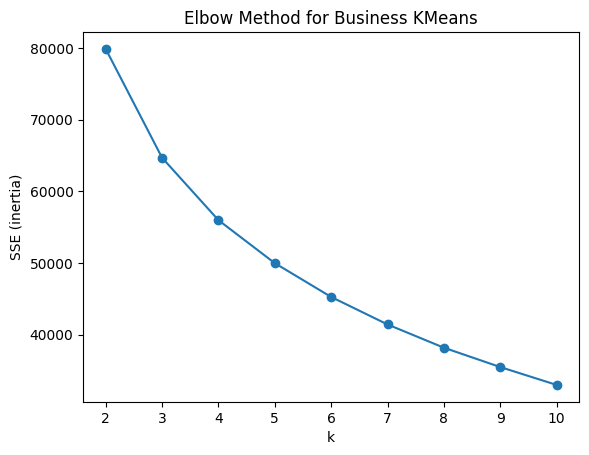

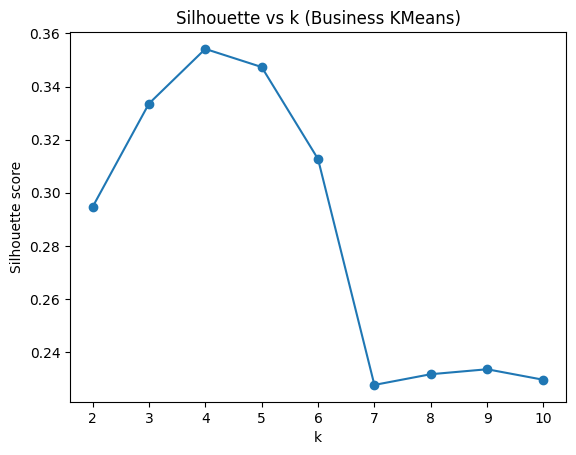

In [16]:
k_list = range(2, 11)
sse_biz = []
sil_biz = []

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_biz_scaled)
    
    sse_biz.append(km.inertia_)
    score = silhouette_score(X_biz_scaled, labels)
    sil_biz.append(score)
    
    print(f"k={k}, silhouette={score:.3f}")

# Elbow 曲线
plt.figure()
plt.plot(k_list, sse_biz, marker="o")
plt.xlabel("k")
plt.ylabel("SSE (inertia)")
plt.title("Elbow Method for Business KMeans")
plt.show()

# Silhouette 曲线
plt.figure()
plt.plot(k_list, sil_biz, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (Business KMeans)")
plt.show()


In [17]:
k_opt_biz = 4

kmeans_biz = KMeans(n_clusters=k_opt_biz, random_state=42, n_init=10)
biz_labels = kmeans_biz.fit_predict(X_biz_scaled)

# 把聚类结果写回 biz_df2
biz_df2["biz_cluster"] = biz_labels

# 看每个商家簇的数量
print(biz_df2["biz_cluster"].value_counts().sort_index())


biz_cluster
0    2749
1    6700
2     400
3     350
Name: count, dtype: int64


In [18]:
biz_cluster_profile = biz_df2.groupby("biz_cluster")[biz_feature_cols].mean()
print(biz_cluster_profile)


             biz_stars  biz_review_count  checkin_count  is_open  \
biz_cluster                                                        
0             2.649327         76.610768     144.782466      1.0   
1             4.157910        137.083881     257.327164      1.0   
2             4.096250        928.095000    1919.985000      1.0   
3             4.092857         90.991429     378.248571      1.0   

             mean_review_stars  mean_text_len  mean_user_review_count  \
biz_cluster                                                             
0                     2.141975     117.664840               52.649645   
1                     4.141379      85.826697               89.897479   
2                     4.059663      93.969368               97.698009   
3                     4.089286     110.917809              487.723315   

             mean_user_average_stars  mean_user_fans     n_users   n_reviews  
biz_cluster                                                              

In [19]:
biz_overall_mean = X_biz.mean()
biz_overall_std = X_biz.std()

biz_cluster_profile_z = (biz_cluster_profile - biz_overall_mean) / biz_overall_std
print(biz_cluster_profile_z.round(2))


             biz_stars  biz_review_count  checkin_count  is_open  \
biz_cluster                                                        
0                -1.24             -0.29          -0.16      NaN   
1                 0.47             -0.05          -0.04      NaN   
2                 0.40              3.01           1.73      NaN   
3                 0.39             -0.23           0.09      NaN   

             mean_review_stars  mean_text_len  mean_user_review_count  \
biz_cluster                                                             
0                        -1.36           0.57                   -0.33   
1                         0.51          -0.25                   -0.03   
2                         0.43          -0.04                    0.03   
3                         0.46           0.39                    3.20   

             mean_user_average_stars  mean_user_fans  n_users  n_reviews  
biz_cluster                                                               
0 

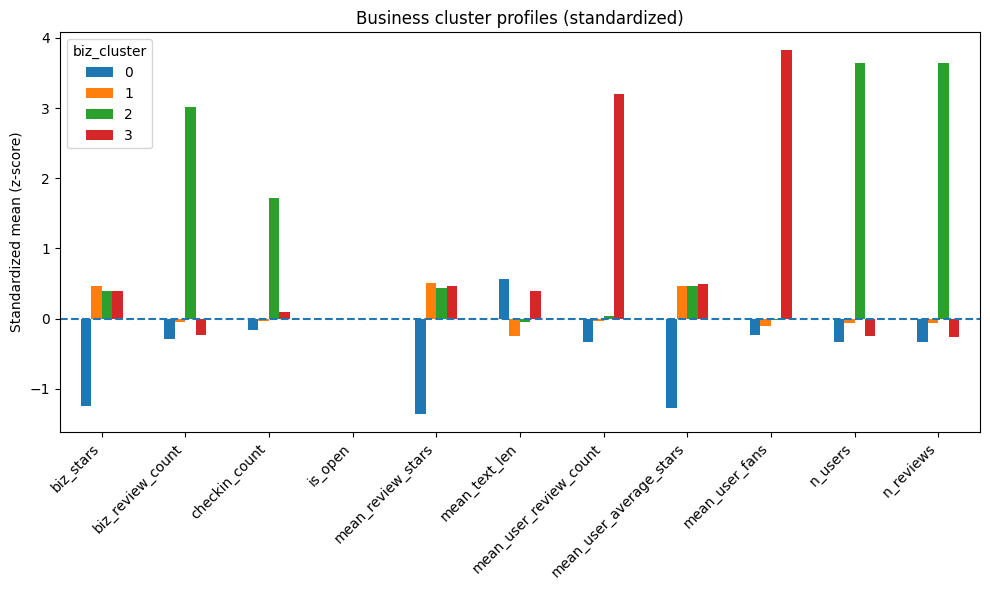

In [20]:
biz_cluster_profile_z.T.plot(kind="bar", figsize=(10,6))
plt.axhline(0, linestyle="--")
plt.ylabel("Standardized mean (z-score)")
plt.title("Business cluster profiles (standardized)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Cluster 0 （2749 家）
* biz_stars ≈ -1.24，mean_review_stars ≈ -1.36
* 用户平均评分 mean_user_average_stars ≈ -1.28
* biz_review_count, checkin_count, n_users, n_reviews 都略低于平均
* mean_text_len ≈ +0.57（评论偏长）

低评分、低人气、被挑剔用户光顾的小店：
* 店本身 Yelp 评分偏低，来访用户整体也习惯打低分；
* 评论数量和访问人数都略少，但评论文字比较长（可能抱怨较多）。
低评分小众店 / 问题店；Low-rated niche businesses

Cluster 1 （6700 家）
* biz_stars ≈ +0.47，mean_review_stars ≈ +0.51（评分略高）
* 其他指标（review_count, checkin, n_users, n_reviews, 用户特征）都接近 0（平均水平附近）
* mean_text_len ≈ -0.25（评论稍短）

评分不错、规模中等的普通店：
* 在平台上的曝光、人流都接近总体平均；
* 评分略高于平均，是“还不错”的主流商家。
中等人气的优质店；Mainstream well-rated businesses

Cluster 2 （400 家）
* biz_review_count ≈ +3.01，checkin_count ≈ +1.73
8 n_users, n_reviews ≈ +3.6（访问人数和评论条数都非常高）
* 评分相关：biz_stars, mean_review_stars, mean_user_average_stars 都略高于平均
* 用户粉丝 mean_user_fans ≈ +0.32

超高人气、评分也不错的头部热门店:
* 评论和访客数量远高于平均，是平台上的“流量王”；
* 评分也偏高，来访用户整体比较正向，粉丝略多。
高人气热门店;High-traffic popular hotspots

Cluster 3 （350 家）
* 评分相关：biz_stars, mean_review_stars 略高于平均
* mean_text_len ≈ +0.39（评论偏长）
* mean_user_average_stars 很高（z≈3+），
* mean_user_fans 也明显高于平均
* biz_review_count, n_users, n_reviews 略低于平均或接近平均

被高分、粉丝多的用户偏爱的小而精商家:
* 店本身评分不错，但并不是特别“流量爆款”；
* 来的多是整体打分高、粉丝也多的用户，评论偏长、质量高。
高质量小众店 / 网红客群偏爱的店;Influencer-focused niche businesses

# User × Business

In [21]:
# 1. user_id -> user_cluster 映射
user_cluster_map = user_df2[["cluster"]].reset_index()   # index=user_id
# 列名：user_id, cluster

# 2. business_id -> biz_cluster 映射
biz_cluster_map = biz_df2[["biz_cluster"]].reset_index() # index=business_id
# 列名：business_id, biz_cluster

# 3. 合并到原始 df（只保留完成聚类的用户 & 商家）
df_all = df.merge(user_cluster_map, on="user_id", how="inner")
df_all = df_all.merge(biz_cluster_map, on="business_id", how="inner")

print(df_all.shape)
print(df_all[["user_id", "business_id", "cluster", "biz_cluster"]].head())


(86492, 27)
                  user_id             business_id  cluster  biz_cluster
0  j4qNLF-VNRF2DwBkUENW-w  yE1raqkLX7OZsjmX3qKIKg        2            2
1  aIJ-FOGqoQjp7eUCfcIXuA  rQW9iupvhk6ScPn2VPNLVQ        2            1
2  EyKg8vj7GM3FMCBqMEdaLg  X5fWO9e82EICHXzzs6eQMg        2            1
3  js4Sl3Enl7ZrEM_bOQcPxA  94Kq5YyU6C8cwgdh4_ozjw        2            0
4  BXBtET2Kk7MmsqEXYySXtg  7lwe7n-Yc-V9E_HfLAeylg        0            1


In [22]:
user_biz_tab = pd.crosstab(
    df_all["cluster"], 
    df_all["biz_cluster"], 
    normalize="index"   # 每一行标准化为占比
)

print(user_biz_tab)


biz_cluster         0         1         2         3
cluster                                            
0            0.077247  0.677296  0.193652  0.051805
1            0.322155  0.513267  0.151555  0.013023
2            0.062767  0.643849  0.266719  0.026664
3            0.007168  0.261649  0.179211  0.551971


The cross-tabulation between user clusters and business clusters reveals clear preference patterns:

* Critical users (User Cluster 1) are disproportionately associated with low-rated niche businesses (Business Cluster 0). About 32% of their reviews fall into Cluster 0, compared with only 6–8% for the other user groups. This confirms that critical users are more likely to visit and complain about problematic businesses, making them an important source of negative word-of-mouth.
* Mainstream positive users (Cluster 2) and active local experts (Cluster 0) mainly review mainstream well-rated businesses (Business Cluster 1), with shares of approximately 64% and 68%, respectively. They also allocate a non-trivial portion of their reviews (19–27%) to high-traffic popular hotspots (Business Cluster 2), indicating a strong preference for well-known, well-rated places.
* Super influencers (Cluster 3) are highly concentrated on influencer-focused niche businesses (Business Cluster 3). More than 55% of their reviews target Cluster 3, whereas the other user segments contribute only 1–5% of reviews in this segment. This suggests that super influencers tend to explore high-quality but relatively less mainstream venues and have a disproportionate impact on their reputation.

Overall, the joint clustering shows a clear interaction between user behavior segments and business segments: critical users amplify the visibility of low-quality businesses, mainstream users and local experts support the bulk of average-to-good venues, and a small group of super influencers primarily promote high-quality niche businesses.